modify from TOI2431_onlyRVs_mod144_original.ipynb

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import collections
import matplotlib.gridspec as gridspec # GRIDSPEC !
import collections
import matplotlib
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

In [2]:
def plots_in_grid():
    # Partially taken from here:
    # http://www.sc.eso.org/~bdias/pycoffee/codes/20160407/gridspec_demo.html
    
    gs = gridspec.GridSpec(2,1, height_ratios=[3.0,1.0])
    # Also make sure the margins and spacing are apropriate
    gs.update(left=0.2, right=0.95, bottom=0.08, top=0.93, wspace=0.02, hspace=0.03)
    
    
    ax_0 = plt.subplot(gs[0])
    ax_1 = plt.subplot(gs[1])

    # Adding minor ticks only to x axis
    from matplotlib.ticker import AutoMinorLocator
    minorLocator = AutoMinorLocator()
    ax_0.xaxis.set_minor_locator(minorLocator)
    ax_1.xaxis.set_minor_locator(minorLocator)

    # Disabling the offset on top of the plot
    ax_0.ticklabel_format(useOffset=False, style='plain')
    ax_1.ticklabel_format(useOffset=False, style='plain')
    return ax_0, ax_1

In [3]:
# dir_base = '../'
# dir_mods = 'RVonly_analysis_20250821/TOI2431_onlyRVs_mod144_SPLEAFframework_Sindex_4p/'
# dir_plot = 'dynesty_plot/model_files/'
# filename = 'TOI2431_onlyRVs_mod144_SPLEAFframework_Sindex_4p'

# summary_percentiles_parameters = pickle.load(open(dir_base + dir_mods + 'dynesty_plot/dictionaries/summary_percentiles_parameters.p', 'rb'))
# summary_percentiles_derived = pickle.load(open(dir_base + dir_mods + 'dynesty_plot/dictionaries/summary_percentiles_derived.p', 'rb'))

dir_base = './'
dir_mods = 'HD189567_3p_run7/'
dir_plot = 'emcee_plot/model_files/'
filename = 'HD189567_3p_run7'

summary_percentiles_parameters = pickle.load(open(dir_base + dir_mods + 'emcee_plot/dictionaries/summary_percentiles_parameters.p', 'rb'))
summary_percentiles_derived = pickle.load(open(dir_base + dir_mods + 'emcee_plot/dictionaries/summary_percentiles_derived.p', 'rb'))

#planet_dict = collections.OrderedDict()
#planet_dict['b'] =  {
#    'P': summary_percentiles_parameters['b']['K'][3],
#    'Tc': summary_percentiles_derived['b']['Tc'][3],
#    #'limits_folded_x': [-0.25, 1.25],
#    'limits_folded_x': [-0.75, 0.75],
#    #'limits_folded_y': [-67.8, 67.8],
#    #'limits_residuals_y': [-5.5, 5.5],
#    'transit_folded': True,
#    'K_error': (summary_percentiles_parameters['b']['K'][4] - summary_percentiles_parameters['b']['K'][2])/2
#}
#
#planet_dict['c'] =  {
#    'P': summary_percentiles_parameters['c']['K'][3], # 0.446547,
#    'Tc': 9002.834351,
#    'limits_folded_x': [-0.75, 0.75],
#    'limits_folded_y': [-11, 11],
#    'limits_residuals_y': [-5.5, 5.5],
#    'transit_folded': False,
#    'K_error': (summary_percentiles_parameters['c']['K'][4] - summary_percentiles_parameters['c']['K'][2])/2
#}



# Comment/uncomment according to the number of datasets and their names
#datasets_list = ['RVdata_dataset1', 'RVdata_dataset2'] 
datasets_list = ['RVdata']
datasets_labels = {'RVdata':'RV'}

# Comment/uncomment according to the models listed in your configuration files
activity_model = 'gp_multidimensional'

activity_list = ['BISdata', 'FWHMdata']
activity_labels = {'BISdata':'BIS',
                  'FWHMdata':'FWHM',
                  }

# ============================================================================
# PLANET CONFIGURATION
# ============================================================================
planet_dict = collections.OrderedDict()

# Planet b configuration
planet_name = 'b'
planet_dict[planet_name] = {
    'P': summary_percentiles_parameters[planet_name]['P'][3],  # Median value (index 3)
    # 'Tc': summary_percentiles_derived[planet_name]['Tc'][3],  # Uncomment if you have derived parameters
    'limits_folded_x': [-0.25, 1.25],
    'transit_folded': False,
    'K_error_1sigma': (summary_percentiles_parameters[planet_name]['K'][4] - summary_percentiles_parameters[planet_name]['K'][2])/2,
    'K_error_2sigma': (summary_percentiles_parameters[planet_name]['K'][5] - summary_percentiles_parameters[planet_name]['K'][1])/2,
    'K_error_3sigma': (summary_percentiles_parameters[planet_name]['K'][6] - summary_percentiles_parameters[planet_name]['K'][0])/2,
}

# Planet c configuration
planet_name = 'c'
planet_dict[planet_name] = {
    'P': summary_percentiles_parameters[planet_name]['P'][3],  # Median value (index 3)
    # 'Tc': summary_percentiles_derived[planet_name]['Tc'][3],  # Uncomment if you have derived parameters
    'limits_folded_x': [-0.25, 1.25],
    'transit_folded': False,
    'K_error_1sigma': (summary_percentiles_parameters[planet_name]['K'][4] - summary_percentiles_parameters[planet_name]['K'][2])/2,
    'K_error_2sigma': (summary_percentiles_parameters[planet_name]['K'][5] - summary_percentiles_parameters[planet_name]['K'][1])/2,
    'K_error_3sigma': (summary_percentiles_parameters[planet_name]['K'][6] - summary_percentiles_parameters[planet_name]['K'][0])/2,
}

# ============================================================================
# ACTIVITY AND FULL DICTIONARY CONFIGURATION
# ============================================================================
activity_dict = {
    'limits_full_x': [-0.25, 1.25],
    'limits_bjd': [2455480., 2460211.522268],
    # 'limits_full_y': [-13.5, 13.5],
    # 'limits_residuals_y': [-11.5, 11.5],
}

full_dict = {
    'reference_planet': 'b',
    'limits_full_x': [-0.25, 1.25],
    'limits_bjd': [2455480., 2460211.522268],
}

In [4]:
planet_dict

OrderedDict([('b',
              {'P': 14.291301272005711,
               'limits_folded_x': [-0.25, 1.25],
               'transit_folded': False,
               'K_error_1sigma': 0.13363001508971606,
               'K_error_2sigma': 0.2674536039177605,
               'K_error_3sigma': 0.4004095944048116}),
             ('c',
              {'P': 33.67706456886967,
               'limits_folded_x': [-0.25, 1.25],
               'transit_folded': False,
               'K_error_1sigma': 0.16316895672452103,
               'K_error_2sigma': 0.3272896769064887,
               'K_error_3sigma': 0.4899893938758938})])

Planet  b , RV curve folded around the reference time
Folded plot for planet  b  saved to: HD189567_3p_run7_b_folded.png
Planet  c , RV curve folded around the reference time
Folded plot for planet  c  saved to: HD189567_3p_run7_c_folded.png


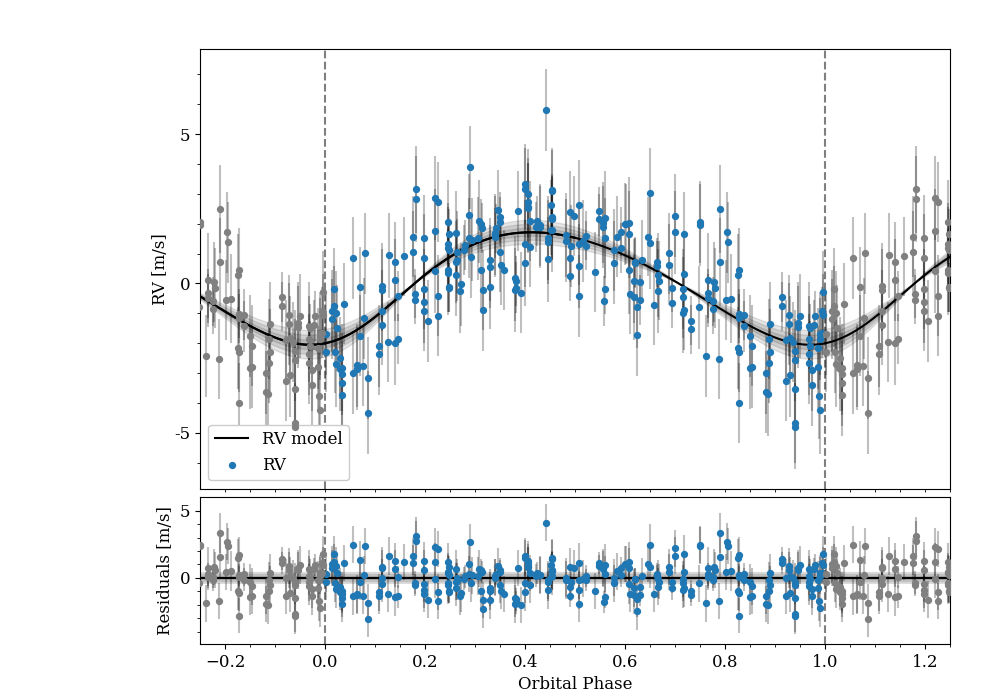

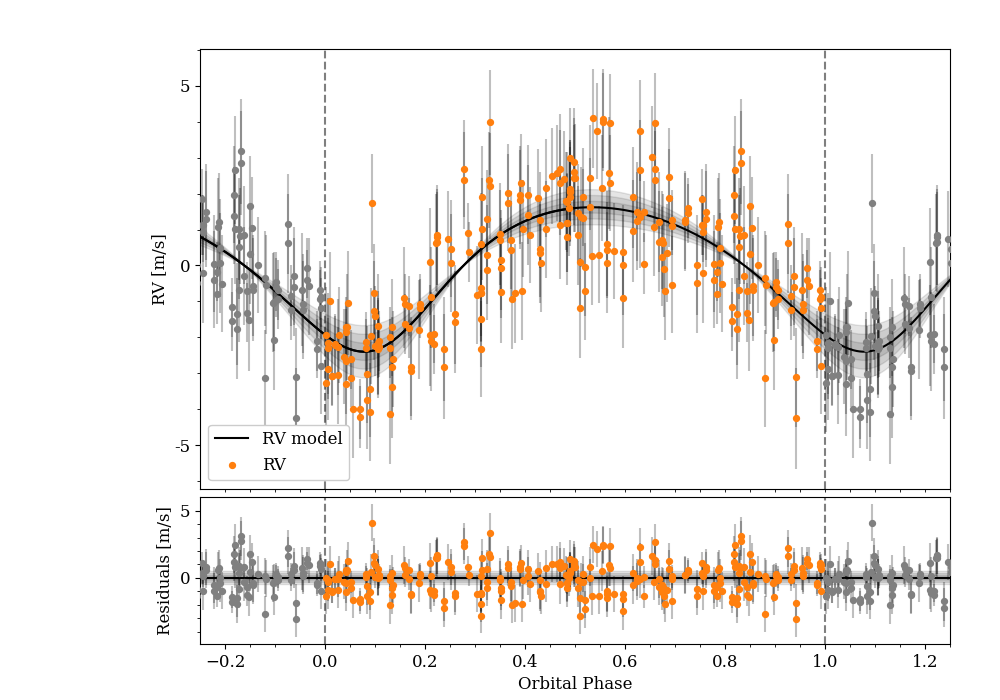

In [5]:
# Folder RV plot for each of the planet

font_label = 12
dot_size = 18


figsize = ((10,7))

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams.update({'font.size': font_label})

n_figure = 0
n_color = 0

for key_name, key_val in planet_dict.items():
    #RV_full = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RVdata_HARPN_full.dat', skip_header=1)


    #sel = (RV_mod_temp[:,9] < 7.8)
    #RV_mod = RV_mod_temp[sel,:]
    
    #RV_mod = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RVdata_HARPN_radial_velocities_'+key_name+'.dat', skip_header=1)
    #RV_mod_full = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RVdata_HARPN_radial_velocities_'+key_name+'_full.dat', skip_header=1)
    RV_kep = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RV_planet_'+key_name+'_kep.dat', skip_header=1)

    if key_val.get('transit_folded',True):
        RV_pha = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RV_planet_'+key_name+'_Tcf.dat', skip_header=1)
    else:
        RV_pha = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RV_planet_'+key_name+'_pha.dat', skip_header=1)


    
    fig = plt.figure(figsize=figsize)

    ax_0, ax_1 = plots_in_grid()
    
    K_error_1sigma = key_val['K_error_1sigma']
    K_error_2sigma = key_val['K_error_2sigma']
    K_error_3sigma = key_val['K_error_3sigma']
    K_rvs = np.amax(RV_pha[:,1])
    RV_unitary = RV_pha[:,1] / K_rvs
    ax_0.fill_between(RV_pha[:,0], RV_unitary*(K_rvs-K_error_1sigma), y2=RV_unitary*(K_rvs+K_error_1sigma), alpha=0.10, color='black', zorder=0)
    ax_0.fill_between(RV_pha[:,0], RV_unitary*(K_rvs-K_error_2sigma), y2=RV_unitary*(K_rvs+K_error_2sigma), alpha=0.10, color='black', zorder=0)
    ax_0.fill_between(RV_pha[:,0], RV_unitary*(K_rvs-K_error_3sigma), y2=RV_unitary*(K_rvs+K_error_3sigma), alpha=0.10, color='black', zorder=0)
    
    
    # Plot of the model
    ax_0.plot(RV_pha[:,0]-1,RV_pha[:,1], color='k', linestyle='-', zorder=2, label='RV model')
    ax_0.plot(RV_pha[:,0]+1,RV_pha[:,1], color='k', linestyle='-', zorder=2)

    default_color = 'C' + repr(n_color)
    n_color += 1
    
    for n_dataset, dataset in enumerate(datasets_list):
        #default_color = 'C' + repr(n_dataset)

        RV_mod = np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_radial_velocities_'+key_name+'.dat', skip_header=1)
        #sel = (RV_mod_temp[:,9] < 4)
        #RV_mod = RV_mod_temp[sel,:]
    
        error = np.sqrt(RV_mod[:,9]**2 + RV_mod[:,12]**2)
    
        if key_val.get('transit_folded',False):
            rv_phase = RV_mod[:,1] / planet_dict[key_name]['P']
        else:
            rv_phase = RV_mod[:,2]
        
        ax_0.errorbar(rv_phase, RV_mod[:,8], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
        ax_0.scatter(rv_phase, RV_mod[:,8], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0, label=datasets_labels[dataset])

        # Adding points at phase-1
        ax_0.errorbar(rv_phase-1, RV_mod[:,8], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
        ax_0.scatter(rv_phase-1, RV_mod[:,8], c='gray', s=dot_size, zorder=20, alpha=1.0)

        # Adding points at phase+1
        ax_0.errorbar(rv_phase+1, RV_mod[:,8], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
        ax_0.scatter(rv_phase+1, RV_mod[:,8], c='gray', s=dot_size, zorder=20, alpha=1.0)


        # plot of the residuals
        ax_1.errorbar(rv_phase, RV_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
        ax_1.scatter(rv_phase, RV_mod[:,10], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0)

        # Adding points at phase-1
        ax_1.errorbar(rv_phase-1, RV_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
        ax_1.scatter(rv_phase-1, RV_mod[:,10], c='gray', s=dot_size, zorder=20, alpha=1.0)

        # Adding points at phase+1
        ax_1.errorbar(rv_phase+1, RV_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
        ax_1.scatter(rv_phase+1, RV_mod[:,10], c='gray', s=dot_size, zorder=20, alpha=1.0)

    
    
    
    ax_1.axhline(0.000, c='k', zorder=3)
    ax_1.fill_between(RV_pha[:,0], -K_error_1sigma, K_error_1sigma, alpha=0.10, color='black', zorder=0)
    ax_1.fill_between(RV_pha[:,0], -K_error_2sigma, K_error_2sigma, alpha=0.10, color='black', zorder=0)
    ax_1.fill_between(RV_pha[:,0], -K_error_3sigma, K_error_3sigma, alpha=0.10, color='black', zorder=0)



    if key_val.get('limits_folded_x', False):
        ax_0.set_xlim(key_val['limits_folded_x'][0], key_val['limits_folded_x'][1])
        ax_1.set_xlim(key_val['limits_folded_x'][0], key_val['limits_folded_x'][1])
    if key_val.get('limits_folded_y', False):
        ax_0.set_ylim(key_val['limits_folded_y'][0], key_val['limits_folded_y'][1])
    if key_val.get('limits_residuals_y', False):
        ax_1.set_ylim(key_val['limits_residuals_y'][0], key_val['limits_residuals_y'][1])

        
    if key_val.get('transit_folded', False):
        print('Planet ',key_name,', RV curve folded around the transit time')
        ax_0.axvline(-0.500, c='k', zorder=3, alpha=0.5, linestyle='--')
        ax_0.axvline(0.500, c='k', zorder=3, alpha=0.5, linestyle='--')

        ax_1.axvline(-0.500, c='k', zorder=3, alpha=0.5, linestyle='--')
        ax_1.axvline(0.500, c='k', zorder=3, alpha=0.5, linestyle='--')
    else:
        print('Planet ',key_name,', RV curve folded around the reference time')
        ax_0.axvline(0.00, c='k', zorder=3, alpha=0.5, linestyle='--')
        ax_0.axvline(1.00, c='k', zorder=3, alpha=0.5, linestyle='--')

        ax_1.axvline(0.00, c='k', zorder=3, alpha=0.5, linestyle='--')
        ax_1.axvline(1.00, c='k', zorder=3, alpha=0.5, linestyle='--')        

    ax_0.axes.get_xaxis().set_ticks([])

    ax_0.yaxis.set_major_locator(MultipleLocator(5))
    ax_0.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    # For the minor ticks, use no labels; default NullFormatter.
    ax_0.yaxis.set_minor_locator(MultipleLocator(1))
    
    
    ax_1.yaxis.set_major_locator(MultipleLocator(5))
    ax_1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    # For the minor ticks, use no labels; default NullFormatter.
    ax_1.yaxis.set_minor_locator(MultipleLocator(1))
    
    ax_0.set_ylabel('RV [m/s]')
    ax_1.set_xlabel('Orbital Phase')
    ax_1.set_ylabel('Residuals [m/s]')
    
    ax_0.legend(framealpha=1.0, loc='lower left')
    plot_filename = filename+'_'+key_name+'_folded.png'
    print('Folded plot for planet ',key_name,' saved to:', plot_filename )
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

In [6]:
dir_base + dir_mods + dir_plot 

'./HD189567_3p_run7/emcee_plot/model_files/'

In [7]:
# np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_radial_velocities_b.dat', skip_header=1) == np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_radial_velocities_c.dat', skip_header=1)

RVdata
Folded plot for planet  b  saved to: HD189567_3p_run7_full_model.png


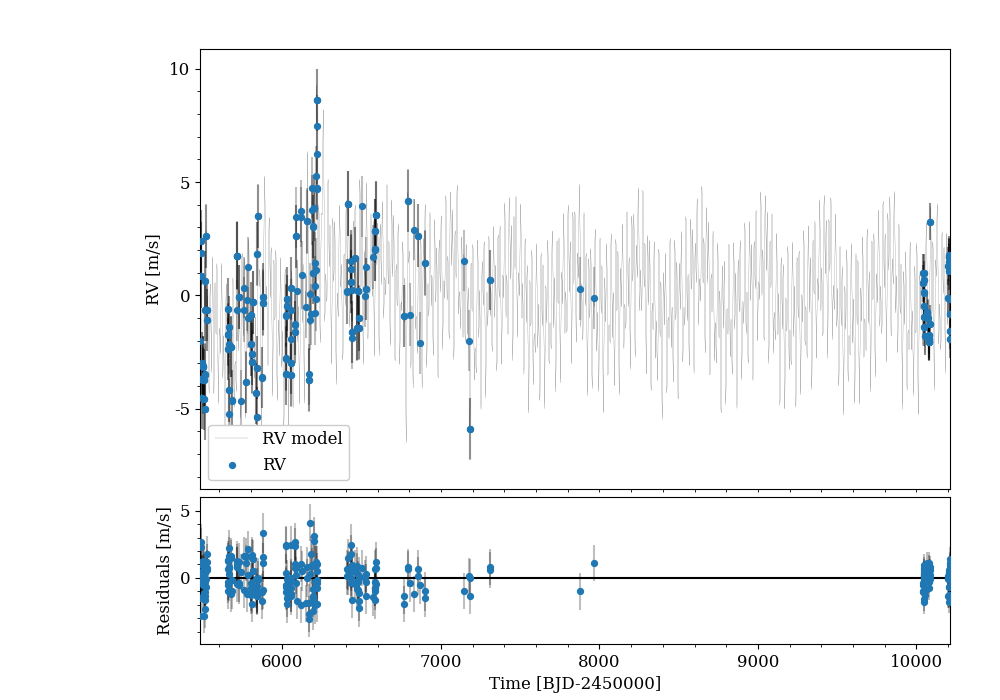

In [8]:
# Folded RV plot for each of the planet

font_label = 12
dot_size = 18
key_name = 'b'


figsize = ((10,7))

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams.update({'font.size': font_label})


n_figure = 0
n_color = 0




    
fig = plt.figure(figsize=figsize)

ax_0, ax_1 = plots_in_grid()

default_color = 'C0'




# Plot of the model
RV_full = np.genfromtxt(dir_base + dir_mods + dir_plot + 'RVdata_full.dat', skip_header=1)
ax_0.plot(RV_full[:,0]-2450000,RV_full[:,1], color='k', linestyle='-', zorder=2, label='RV model', lw=0.1)



for n_dataset, dataset in enumerate(datasets_list):
    print(dataset)
    default_color = 'C' + repr(n_dataset)

    RV_mod = np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_radial_velocities_'+key_name+'.dat', skip_header=1)
    error = np.sqrt(RV_mod[:,9]**2 + RV_mod[:,12]**2)

    ax_0.errorbar(RV_mod[:,0]-2450000, RV_mod[:,7]-RV_mod[:,5], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
    ax_0.scatter(RV_mod[:,0]-2450000, RV_mod[:,7]-RV_mod[:,5], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0, label=datasets_labels[dataset])

    # plot of the residuals
    ax_1.errorbar(RV_mod[:,0]-2450000, RV_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
    ax_1.scatter(RV_mod[:,0]-2450000, RV_mod[:,10], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0)



ax_1.axhline(0.000, c='k', zorder=3)


if full_dict.get('limits_full_y', False):
    ax_0.set_ylim(full_dict['limits_full_y'])
if full_dict.get('limits_residuals_y', False):
    ax_1.set_ylim(full_dict['limits_residuals_y'])

ax_0.set_xlim(full_dict['limits_bjd'][0]-2450000, full_dict['limits_bjd'][1]-2450000,)
ax_1.set_xlim(full_dict['limits_bjd'][0]-2450000, full_dict['limits_bjd'][1]-2450000,)


ax_0.axes.get_xaxis().set_ticks([])

ax_0.yaxis.set_major_locator(MultipleLocator(5))
ax_0.yaxis.set_major_formatter(FormatStrFormatter('%d'))
# For the minor ticks, use no labels; default NullFormatter.
ax_0.yaxis.set_minor_locator(MultipleLocator(1))


ax_1.yaxis.set_major_locator(MultipleLocator(5))
ax_1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
# For the minor ticks, use no labels; default NullFormatter.
ax_1.yaxis.set_minor_locator(MultipleLocator(1))


ax_0.set_ylabel('RV [m/s]')
ax_1.set_xlabel('Time [BJD-2450000]')
ax_1.set_ylabel('Residuals [m/s]')

ax_0.legend(framealpha=1.0, loc='lower left')
plot_filename = filename+'_full_model.png'
print('Folded plot for planet ',key_name,' saved to:', plot_filename )
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')


RVdata
Folded plot for stellar activity saved to: HD189567_3p_run7_activity_RV_model.png


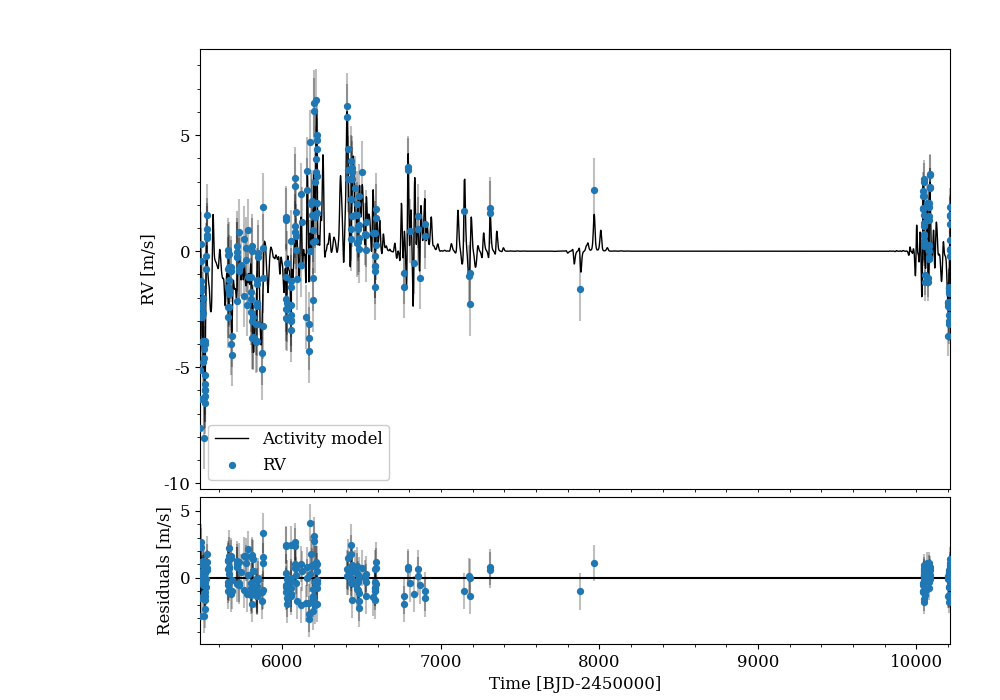

In [9]:

font_label = 12
dot_size = 18
key_name = 'c'


figsize = ((10,7))

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams.update({'font.size': font_label})

default_color = 'C0'


fig = plt.figure(figsize=figsize)

ax_0, ax_1 = plots_in_grid()

# Plot of the model
activity_full = np.genfromtxt(dir_base + dir_mods + dir_plot + datasets_list[0] + '_' + activity_model +'_full.dat', skip_header=1)
ax_0.plot(activity_full[:,0]-2450000.0,activity_full[:,3], color='k', linestyle='-', zorder=2, label='Activity model', lw=1)



for n_dataset, dataset in enumerate(datasets_list):
    print(dataset)
    default_color = 'C' + repr(n_dataset)

    activity_mod = np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_' + activity_model + '.dat', skip_header=1)
    error = np.sqrt(activity_mod[:,9]**2 + activity_mod[:,12]**2)

    ax_0.errorbar(activity_mod[:,0]-2450000.0, activity_mod[:,8], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
    ax_0.scatter(activity_mod[:,0]-2450000.0, activity_mod[:,8], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0, label=datasets_labels[dataset])

    # plot of the residuals
    ax_1.errorbar(activity_mod[:,0]-2450000.0, activity_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
    ax_1.scatter(activity_mod[:,0]-2450000.0, activity_mod[:,10], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0)

    
ax_1.axhline(0.000, c='k', zorder=3)



if activity_dict.get('limits_full_y', False):
    ax_0.set_ylim(activity_dict['limits_full_y'])
if activity_dict.get('limits_residuals_y', False):
    ax_1.set_ylim(activity_dict['limits_residuals_y'])

ax_0.set_xlim(activity_dict['limits_bjd'][0]-2450000, activity_dict['limits_bjd'][1]-2450000,)
ax_1.set_xlim(activity_dict['limits_bjd'][0]-2450000, activity_dict['limits_bjd'][1]-2450000,)


ax_0.axes.get_xaxis().set_ticks([])

ax_0.yaxis.set_major_locator(MultipleLocator(5))
ax_0.yaxis.set_major_formatter(FormatStrFormatter('%d'))
# For the minor ticks, use no labels; default NullFormatter.
ax_0.yaxis.set_minor_locator(MultipleLocator(1))


ax_1.yaxis.set_major_locator(MultipleLocator(5))
ax_1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
# For the minor ticks, use no labels; default NullFormatter.
ax_1.yaxis.set_minor_locator(MultipleLocator(1))

ax_0.set_ylabel('RV [m/s]')
ax_1.set_xlabel('Time [BJD-2450000]')
ax_1.set_ylabel('Residuals [m/s]')

ax_0.legend(framealpha=1.0, loc='lower left')
plot_filename = filename+'_activity_RV_model.png'
print('Folded plot for stellar activity saved to:', plot_filename )
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')


In [12]:
dir_base + dir_mods + dir_plot + dataset + '_' + activity_model +'_full.dat'

'./HD189567_3p_run7/emcee_plot/model_files/FWHMdata_gp_multidimensional_full.dat'

BISdata
Folded plot for stellar activity saved to: HD189567_3p_run7_activity_BISdata.png
FWHMdata
Folded plot for stellar activity saved to: HD189567_3p_run7_activity_FWHMdata.png


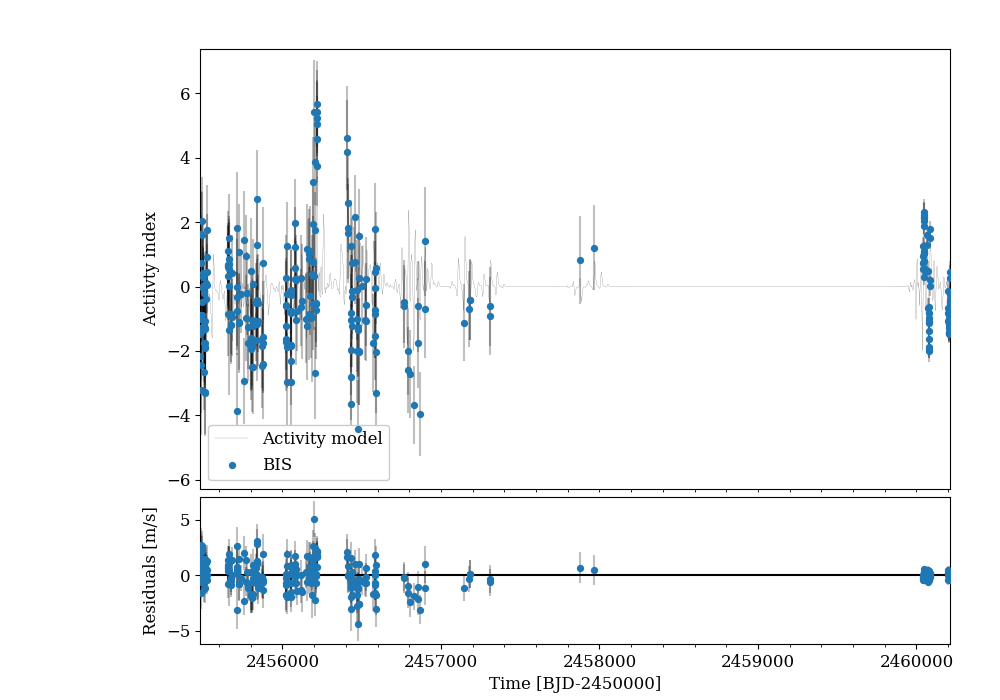

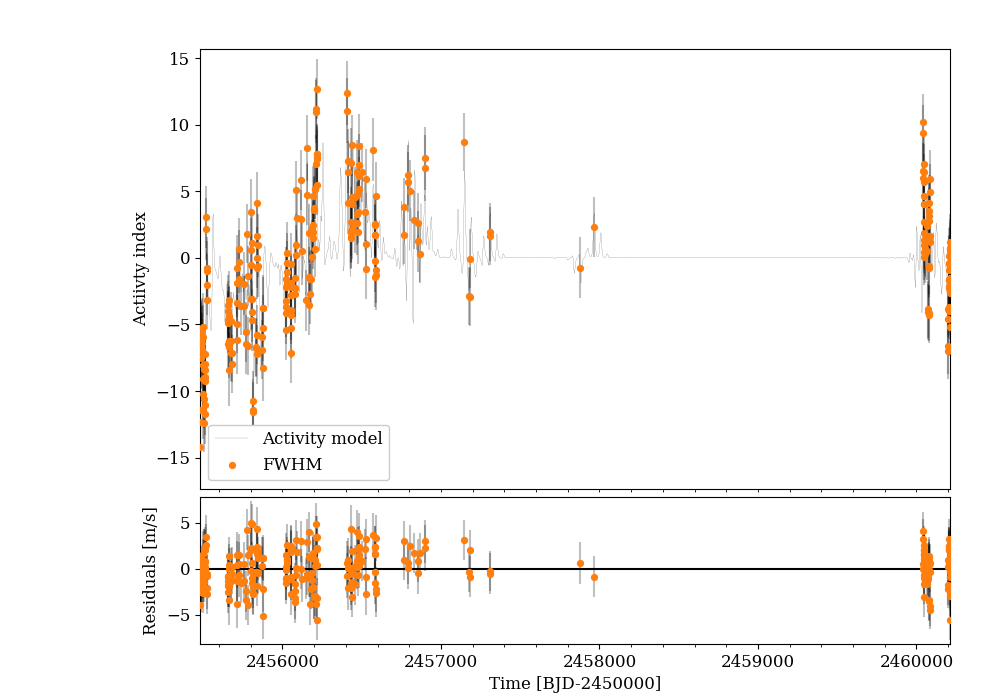

In [10]:

font_label = 12
dot_size = 18
key_name = 'c'


figsize = ((10,7))

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams.update({'font.size': font_label})

default_color = 'C0'



for n_dataset, dataset in enumerate(activity_list):

    fig = plt.figure(figsize=figsize)

    ax_0, ax_1 = plots_in_grid()

    # Plot of the model
    activity_full = np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_' + activity_model +'_full.dat', skip_header=1)
    ax_0.plot(activity_full[:,0],activity_full[:,3], color='k', linestyle='-', zorder=2, label='Activity model', lw=0.1)

    
    
    print(dataset)
    default_color = 'C' + repr(n_dataset)

    activity_mod = np.genfromtxt(dir_base + dir_mods + dir_plot + dataset + '_' + activity_model + '.dat', skip_header=1)
    error = np.sqrt(activity_mod[:,9]**2 + activity_mod[:,12]**2)

    ax_0.errorbar(activity_mod[:,0], activity_mod[:,8], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=0)
    ax_0.scatter(activity_mod[:,0], activity_mod[:,8], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0, label=activity_labels[dataset])

    # plot of the residuals
    ax_1.errorbar(activity_mod[:,0], activity_mod[:,10], yerr=error, color='black', markersize=0, alpha=0.25, fmt='o', zorder=1)
    ax_1.scatter(activity_mod[:,0], activity_mod[:,10], c=default_color, s=dot_size, zorder=20-n_dataset, alpha=1.0)


    ax_1.axhline(0.000, c='k', zorder=3)


    val_min, val_max = np.amin(activity_mod[:,8]-error), np.amax(activity_mod[:,8]+error)
    res_min, res_max = np.amin(activity_mod[:,10]-error), np.amax(activity_mod[:,10]+error)
    
    ax_0.set_xlim(activity_dict['limits_bjd'])
    ax_0.set_ylim(val_min - np.abs(val_min)*0.05, val_max + np.abs(val_max)*0.05)

    ax_1.set_xlim(activity_dict['limits_bjd'])
    ax_1.set_ylim(res_min - np.abs(res_min)*0.05, res_max + np.abs(res_max)*0.05)

    ax_0.axes.get_xaxis().set_ticks([])

    #ax_0.yaxis.set_major_locator(MultipleLocator(5))
    #ax_0.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    ## For the minor ticks, use no labels; default NullFormatter.
    #ax_0.yaxis.set_minor_locator(MultipleLocator(1))
    
    
    #ax_1.yaxis.set_major_locator(MultipleLocator(5))
    #ax_1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    ## For the minor ticks, use no labels; default NullFormatter.
    #ax_1.yaxis.set_minor_locator(MultipleLocator(1))
    
    ax_0.set_ylabel('Actiivty index')
    ax_1.set_xlabel('Time [BJD-2450000]')
    ax_1.set_ylabel('Residuals [m/s]')

    ax_0.legend(framealpha=1.0, loc='lower left')
    plot_filename = filename+'_activity_'+ dataset +'.png'
    print('Folded plot for stellar activity saved to:', plot_filename )
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
